# Linear Regression Model

This notebook is the training and development of the linear regression model. The purpose of this model is to establish a baseline performance for the other models.

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np 
from sklearn.metrics import  r2_score
from pathlib import Path
import matplotlib.pyplot as plt
import joblib
import matplotlib.dates as mdates

### Weather and water only dataset

In [3]:
data_folder = Path(r'..\data\model-ready\water-weather')

##### read in our model ready data

In [4]:
# train
train_X_df = pd.read_parquet(data_folder / 'scaled-X-train.parquet')
train_y_df = pd.read_parquet(data_folder / 'scaled-Y-train.parquet') # the Y data is not actually scaled inspite of the name

# test
test_X_df = pd.read_parquet(data_folder / 'scaled-X-test.parquet')
test_y = pd.read_parquet(data_folder / 'scaled-Y-test.parquet') # the Y data is not actually scaled inspite of the name

# val
val_X_df = pd.read_parquet(data_folder / 'scaled-X-val.parquet')
val_y = pd.read_parquet(data_folder / 'scaled-Y-val.parquet') # the Y data is not actually scaled inspite of the name



In [5]:
scaler = joblib.load(data_folder / 'minmax_scaler.joblib')

##### train the model

In [6]:
model = LinearRegression()
model.fit(train_X_df, train_y_df)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 16)","[[-0.04, 0.16, 0.01,...,-0.01, 6.73,-0.4 ]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](16,)","['TMAX','TMIN','PRCP',...,'cos_day','past_10_day_ave_temp', 'past_10_day_std_temp']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[10.72]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


#### evaluate on validation and test dataset
The two sets are combined here, as the validation set it truly needed for training nueral networks, where a validation set is used to prevent overfitting.

In [7]:
test_val_x = pd.concat([test_X_df, val_X_df], ignore_index=True)
test_val_y = pd.concat([test_y, val_y], ignore_index=True)

In [8]:
y_pred = model.predict(test_val_x)

In [9]:
test_val_x_unscaled = scaler.inverse_transform(test_val_x)

In [10]:
test_val_x = pd.DataFrame(columns=test_val_x.columns, data=test_val_x_unscaled)

In [11]:
test_val_x.head(1)

,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,tmax_c,tmin_c,sin_month,cos_month,sin_day,cos_day,past_10_day_ave_temp,past_10_day_std_temp
0,64.0,56.0,0.93,15.7,15.7,2.0,3.0,1940.0,17.777778,13.333333,0.866025,0.5,0.571268,0.820763,15.59,0.11005


In [12]:
test_val_x['date'] = pd.to_datetime(test_val_x[['year','month','day']], errors='coerce')

In [13]:
test_val_x.head(1)

,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,tmax_c,tmin_c,sin_month,cos_month,sin_day,cos_day,past_10_day_ave_temp,past_10_day_std_temp,date
0,64.0,56.0,0.93,15.7,15.7,2.0,3.0,1940.0,17.777778,13.333333,0.866025,0.5,0.571268,0.820763,15.59,0.11005,1940-02-03


In [14]:
test_val_x['prediction'] = y_pred

In [15]:
test_val_x['target'] = test_val_y

In [16]:
errors = y_pred - test_val_y
test_val_x['errors'] = errors

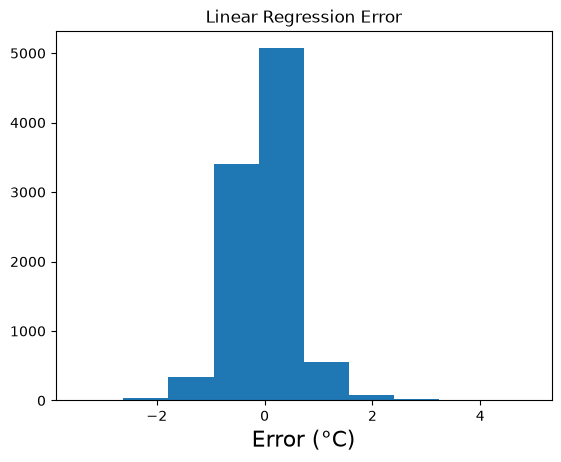

In [17]:
plt.hist(errors)
plt.title('Linear Regression Error')
plt.xlabel('Error (\u00b0C)', fontsize=16)
plt.show()

In [18]:
test_val_x.head(1)

,TMAX,TMIN,PRCP,BOT_TEMP_C,SURF_TEMP_C,month,day,year,tmax_c,tmin_c,sin_month,cos_month,sin_day,cos_day,past_10_day_ave_temp,past_10_day_std_temp,date,prediction,target,errors
0,64.0,56.0,0.93,15.7,15.7,2.0,3.0,1940.0,17.777778,13.333333,0.866025,0.5,0.571268,0.820763,15.59,0.11005,1940-02-03,15.734746,15.6,0.134746


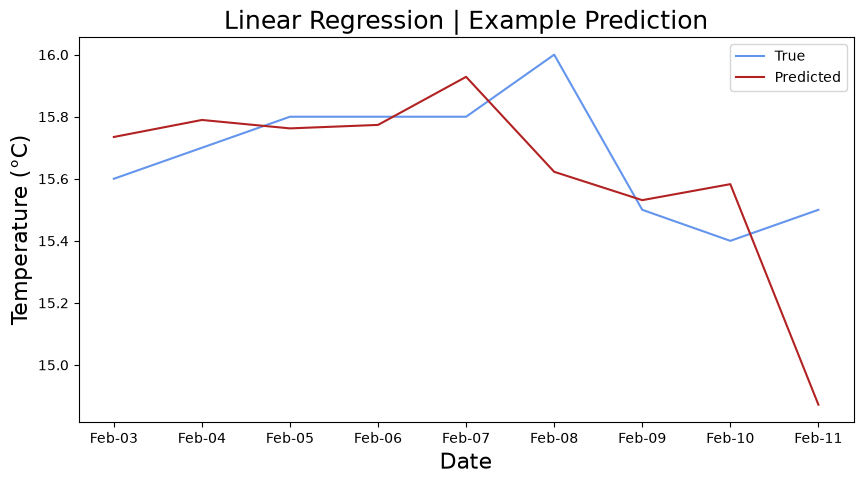

In [19]:
plot_df = test_val_x[:9].copy()
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(plot_df.date, plot_df.target, label='True', color='cornflowerblue')
ax.plot(plot_df.date, plot_df.prediction, label='Predicted', color='firebrick')
ax.set_ylabel('Temperature (\u00b0C)', fontsize=16)
ax.set_xlabel('Date', fontsize=16)
ax.set_title('Linear Regression | Example Prediction', fontsize=18)
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
plt.show()

In [20]:
errors

,target
0,0.134746
1,0.089556
2,-0.037586
3,-0.026384
4,0.128550
...,...
9535,0.294591
9536,-0.034144
9537,-0.026149
9538,0.056957


In [21]:
mse = np.mean([x**2 for x in errors.target])
rmse = np.sqrt(mse)
r_2 = r2_score(test_val_y, y_pred)

print(f'RMSE = {round(rmse, 2)}')
print(f'r2 score = {round(r_2, 2)}')

RMSE = 0.57
r2 score = 0.95


##### Baseline RMSE and R2 Score are 0.57 and 0.96 respectively